<a href="https://www.kaggle.com/code/sarraverse/01-preprocessing-and-eda?scriptVersionId=288969603" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Instacart Market Basket Analysis
# Data Loading, EDA, and Preprocessing for Association Rules

In [1]:
# ============================================================
# Instacart Market Basket Analysis
# Data Loading, EDA, and Preprocessing for Association Rules
# ============================================================

import os
import gc
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 1. Dataset Loading


In [2]:
# ============================================================
# 1. Dataset Loading
# ============================================================
# Adjust paths as needed (Kaggle: /kaggle/input/instacart-market-basket-analysis/)

DATA_DIR = "/kaggle/input/instacart-market-basket-analysis"

orders_path = os.path.join(DATA_DIR, "orders.csv")
order_products_prior_path = os.path.join(DATA_DIR, "order_products__prior.csv")
products_path = os.path.join(DATA_DIR, "products.csv")
aisles_path = os.path.join(DATA_DIR, "aisles.csv")
departments_path = os.path.join(DATA_DIR, "departments.csv")

orders = pd.read_csv(orders_path)
order_products_prior = pd.read_csv(order_products_prior_path)
products = pd.read_csv(products_path)
aisles = pd.read_csv(aisles_path)
departments = pd.read_csv(departments_path)

print("orders:", orders.shape)
print("order_products_prior:", order_products_prior.shape)
print("products:", products.shape)
print("aisles:", aisles.shape)
print("departments:", departments.shape)

display(orders.head())
display(order_products_prior.head())
display(products.head())
display(aisles.head())
display(departments.head())


orders: (3421083, 7)
order_products_prior: (32434489, 4)
products: (49688, 4)
aisles: (134, 2)
departments: (21, 2)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


## 2. Understanding the Files and Relationships

- `orders.csv`  
  Contains order-level information: `order_id`, `user_id`, evaluation set (`eval_set`), order sequence number, day of week, hour of day, and days since prior order.[web:207][web:212]  

- `order_products__prior.csv`  
  Contains the *contents* of prior orders: each row is a product in an order (`order_id`, `product_id`, `add_to_cart_order`, `reordered`). This is the core table for building baskets for association rules.[web:206][web:212]  

- `products.csv`  
  Maps `product_id` to `product_name`, `aisle_id`, and `department_id`.[web:209]  

- `aisles.csv`  
  Maps `aisle_id` to the textual aisle name (e.g., “fresh vegetables”).[web:209]  

- `departments.csv`  
  Maps `department_id` to the department name (e.g., “produce”, “beverages”).[web:209]  

For market basket analysis, the key join path is:

`order_products__prior` → (via `product_id`) → `products` → `aisles` → `departments`, and optionally linking to `orders` (via `order_id` → `user_id`, time info).


## 3. Merge to Build Transaction View (order_id -> list of product names)


In [3]:
# ============================================================
# 3. Merge to Build Transaction View (order_id -> list of product names)
# ============================================================

# Merge order_products_prior with products to get product names and hierarchy
op = order_products_prior.merge(
    products,
    on="product_id",
    how="left"
).merge(
    aisles,
    on="aisle_id",
    how="left"
).merge(
    departments,
    on="department_id",
    how="left"
)

# Optional: merge with orders to get user_id or temporal info if needed later
op = op.merge(
    orders[["order_id", "user_id", "order_dow", "order_hour_of_day", "days_since_prior_order"]],
    on="order_id",
    how="left"
)

display(op.head())
print("Merged table shape:", op.shape)

# Build transaction view: order_id -> list of product names
transactions_df = (
    op.groupby("order_id")["product_name"]
    .apply(list)
    .reset_index()
    .rename(columns={"product_name": "products"})
)

transactions_df["basket_size"] = transactions_df["products"].apply(len)
print("Number of transactions:", transactions_df.shape[0])
display(transactions_df.head())


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,5,9,8.0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,5,9,8.0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,5,9,8.0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,5,9,8.0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,5,9,8.0


Merged table shape: (32434489, 13)
Number of transactions: 3214874


,order_id,products,basket_size
0,2,"[Organic Egg Whites, Michigan Organic Kale, Ga...",9
1,3,[Total 2% with Strawberry Lowfat Greek Straine...,8
2,4,"[Plain Pre-Sliced Bagels, Honey/Lemon Cough Dr...",13
3,5,"[Bag of Organic Bananas, Just Crisp, Parmesan,...",26
4,6,"[Cleanse, Dryer Sheets Geranium Scent, Clean D...",3


## 4. Exploratory Data Analysis (EDA)

We first explore basic properties of the dataset to understand how suitable it is for association rule mining:

- Number of users, orders, and products  
- Distribution of number of items per order  
- Most frequently purchased products  
- Most common aisles and departments  
- Visualization of order sizes  
- Discussion of sparsity (many unique products, many small baskets) and its impact on rules.[web:212][web:210]


### 4.1 Basic counts


In [4]:
# ============================================================
# 4.1 Basic counts
# ============================================================

n_users = orders["user_id"].nunique()
n_orders = orders["order_id"].nunique()
n_products = products["product_id"].nunique()
n_aisles = aisles["aisle_id"].nunique()
n_departments = departments["department_id"].nunique()

print(f"Number of users: {n_users}")
print(f"Number of orders: {n_orders}")
print(f"Number of products: {n_products}")
print(f"Number of aisles: {n_aisles}")
print(f"Number of departments: {n_departments}")


Number of users: 206209
Number of orders: 3421083
Number of products: 49688
Number of aisles: 134
Number of departments: 21


## 4.2 Distribution of number of items per order


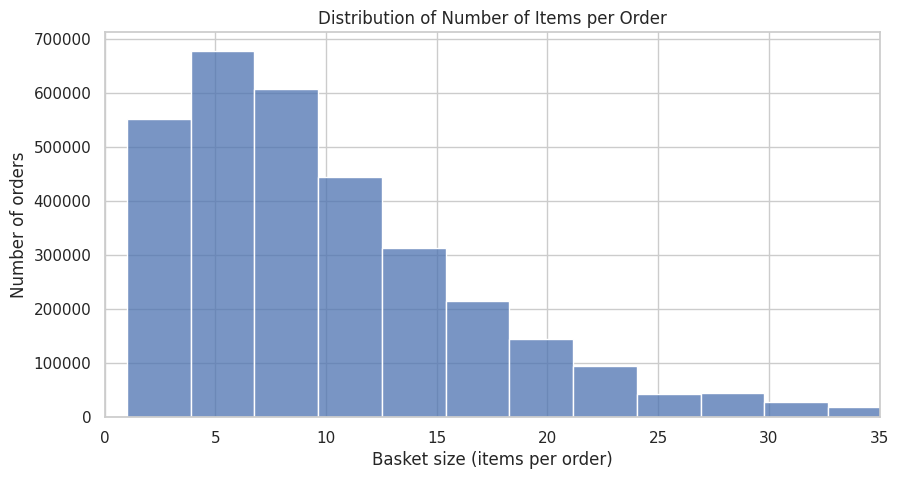

count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: basket_size, dtype: float64


In [5]:
# ============================================================
# 4.2 Distribution of number of items per order
# ============================================================

plt.figure(figsize=(10, 5))
sns.histplot(transactions_df["basket_size"], bins=50, kde=False)
plt.title("Distribution of Number of Items per Order")
plt.xlabel("Basket size (items per order)")
plt.ylabel("Number of orders")
plt.xlim(0, transactions_df["basket_size"].quantile(0.99))
plt.show()

print(transactions_df["basket_size"].describe())


## 4.3 Most frequently purchased products


Number of unique products in prior orders: 49677


,count
Banana,472565
Bag of Organic Bananas,379450
Organic Strawberries,264683
Organic Baby Spinach,241921
Organic Hass Avocado,213584
Organic Avocado,176815
Large Lemon,152657
Strawberries,142951
Limes,140627
Organic Whole Milk,137905


/tmp/ipykernel_55/3812579483.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


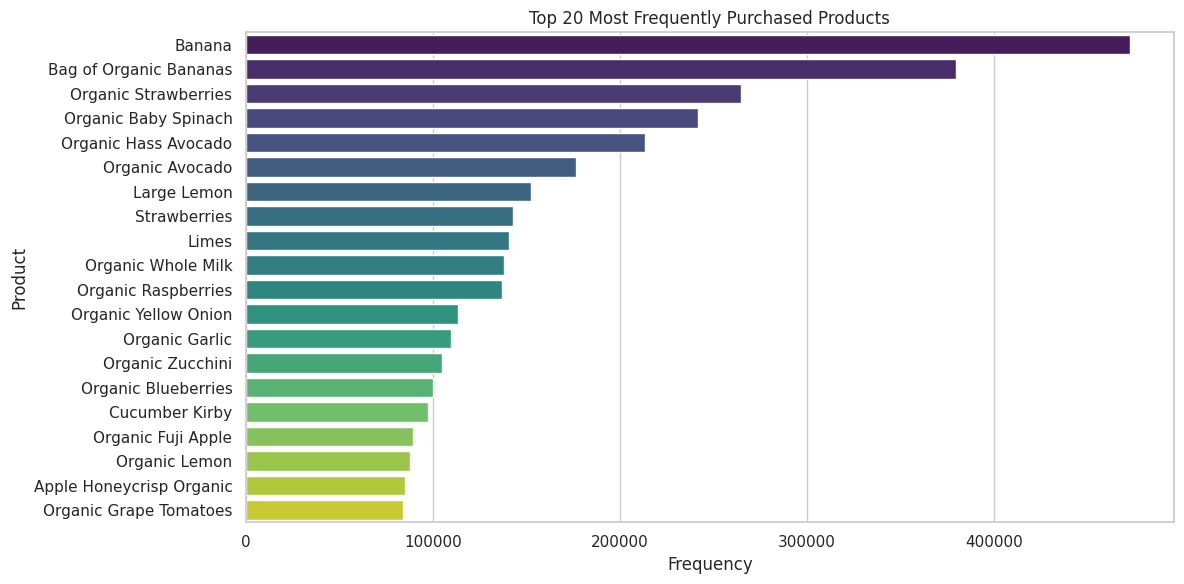

In [6]:
# ============================================================
# 4.3 Most frequently purchased products
# ============================================================

all_products = [p for basket in transactions_df["products"] for p in basket]
product_counts = Counter(all_products)
product_freq_df = (
    pd.DataFrame.from_dict(product_counts, orient="index", columns=["count"])
    .sort_values("count", ascending=False)
)

print("Number of unique products in prior orders:", product_freq_df.shape[0])
display(product_freq_df.head(20))

top_n = 20
top_products = product_freq_df.head(top_n)

plt.figure(figsize=(12, 6))
sns.barplot(
    x=top_products["count"],
    y=top_products.index,
    orient="h",
    palette="viridis"
)
plt.title(f"Top {top_n} Most Frequently Purchased Products")
plt.xlabel("Frequency")
plt.ylabel("Product")
plt.tight_layout()
plt.show()


## 4.4 Most common aisles and departments


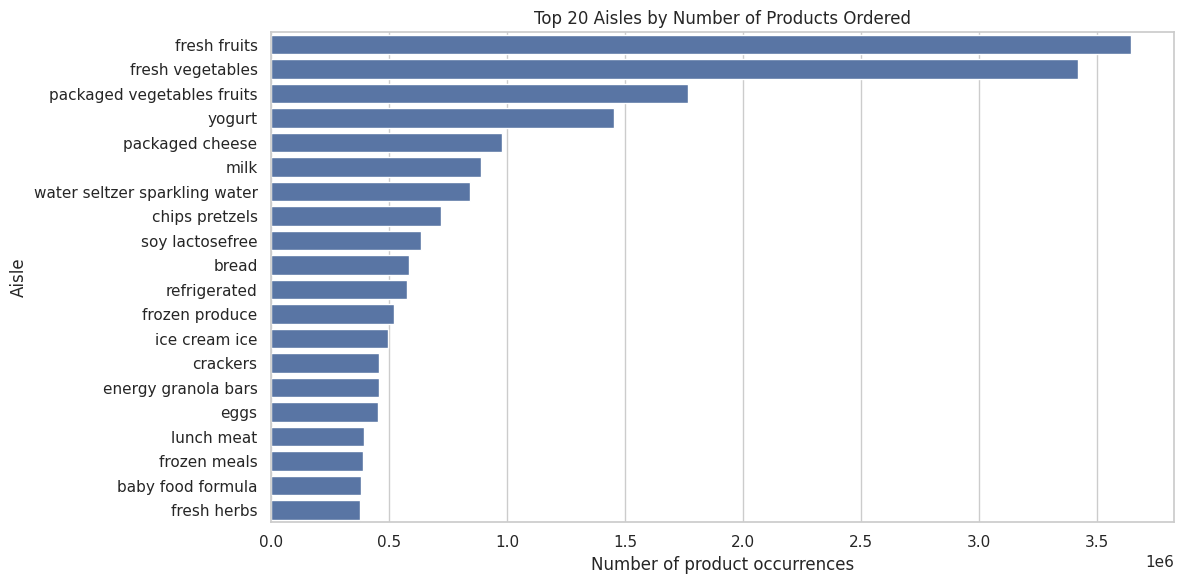

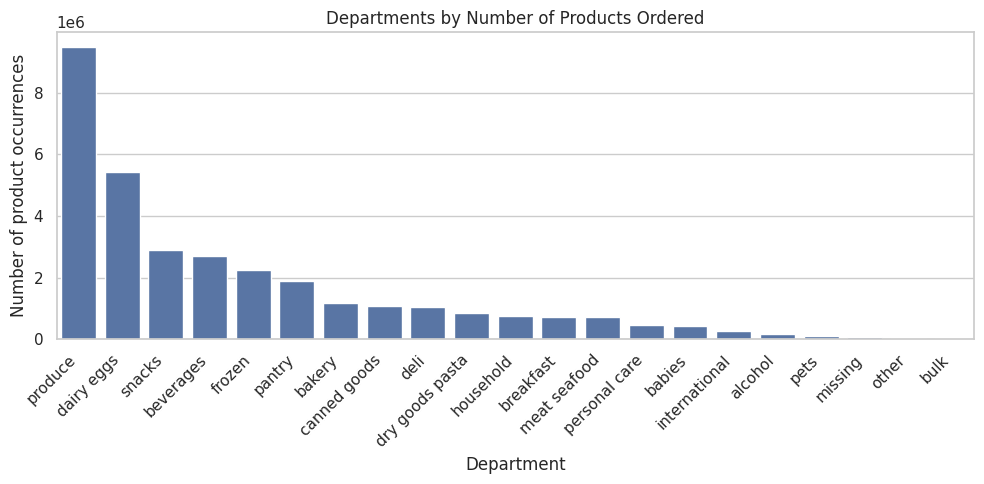

In [7]:
# ============================================================
# 4.4 Most common aisles and departments
# ============================================================

# Aisles
aisle_counts = op.groupby("aisle")["product_id"].count().sort_values(ascending=False)
aisle_counts_df = aisle_counts.reset_index().rename(columns={"product_id": "count"})

plt.figure(figsize=(12, 6))
sns.barplot(
    data=aisle_counts_df.head(20),
    x="count",
    y="aisle",
    orient="h"
)
plt.title("Top 20 Aisles by Number of Products Ordered")
plt.xlabel("Number of product occurrences")
plt.ylabel("Aisle")
plt.tight_layout()
plt.show()

# Departments
dept_counts = op.groupby("department")["product_id"].count().sort_values(ascending=False)
dept_counts_df = dept_counts.reset_index().rename(columns={"product_id": "count"})

plt.figure(figsize=(10, 5))
sns.barplot(
    data=dept_counts_df,
    x="department",
    y="count"
)
plt.title("Departments by Number of Products Ordered")
plt.xlabel("Department")
plt.ylabel("Number of product occurrences")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### 4.5 Sparsity Discussion

From the basket size distribution and the large number of unique products, we can comment on:

- Many orders contain relatively few items (small basket sizes).  
- The product space (`~50k` products) is large compared to typical basket sizes, which implies a **very sparse co‑occurrence matrix**.[web:212][web:219]  

This sparsity is important because:

- Strong association rules require repeated co‑occurrence of item combinations.  
- With many rare products and small baskets, only a subset of popular items will generate meaningful rules.  
This directly motivates filtering very rare products and possibly very small orders before mining.


## 5. Preprocessing for Association Rule Mining


## 5.1 Filter extremely rare products


In [8]:
# ============================================================
# 5. Preprocessing for Association Rule Mining
# ============================================================

# 5.1 Filter extremely rare products
# -----------------------------------
# Justification:
# - Instacart has ~50k products, many of which appear only a few times.
# - Extremely rare products add noise and make the itemset space huge,
#   while contributing little to stable rules.
# - We keep products with at least MIN_PRODUCT_FREQ occurrences
#   across prior orders, to focus on popular items that can yield
#   reliable rules.

MIN_PRODUCT_FREQ = 50  # example; you can adjust and justify in the report

freq_products = product_freq_df[product_freq_df["count"] >= MIN_PRODUCT_FREQ].index
print(f"Products with at least {MIN_PRODUCT_FREQ} occurrences: {len(freq_products)}")

def filter_basket(basket):
    return [p for p in basket if p in freq_products]

transactions_df["products_filtered"] = transactions_df["products"].apply(filter_basket)
transactions_df["basket_size_filtered"] = transactions_df["products_filtered"].apply(len)

# Remove empty baskets after filtering
transactions_df = transactions_df[transactions_df["basket_size_filtered"] > 0].copy()
print("After product filtering:", transactions_df.shape)
print(transactions_df["basket_size_filtered"].describe())


Products with at least 50 occurrences: 26686
After product filtering: (3211567, 5)
count    3.211567e+06
mean     9.964705e+00
std      7.444448e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.300000e+01
max      1.450000e+02
Name: basket_size_filtered, dtype: float64


## 5.2 Optionally filter very small orders (e.g., single-item)


In [9]:
# 5.2 Optionally filter very small orders (e.g., single-item)
# -----------------------------------------------------------
# Justification:
# - Single-item baskets cannot produce A -> B rules.
# - We may choose to remove baskets with size 1 to focus on
#   transactions that can contribute to co-occurrence patterns.

MIN_BASKET_SIZE = 2  # change to 1 if you want to keep all

transactions_df = transactions_df[transactions_df["basket_size_filtered"] >= MIN_BASKET_SIZE].copy()
print("After filtering small baskets:", transactions_df.shape)
print(transactions_df["basket_size_filtered"].describe())


After filtering small baskets: (3051317, 5)
count    3.051317e+06
mean     1.043552e+01
std      7.340845e+00
min      2.000000e+00
25%      5.000000e+00
50%      9.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: basket_size_filtered, dtype: float64


## 6. One-Hot Encoding with TransactionEncoder


In [10]:
# ============================================================
# 6. One-Hot Encoding with TransactionEncoder (Memory-aware)
# ============================================================

from mlxtend.preprocessing import TransactionEncoder

# 6.1 Stronger product frequency filter
# ------------------------------------
# Justification:
# - The full Instacart dataset is huge.
# - We focus on products that appear often enough to form stable rules.
# - Raising MIN_PRODUCT_FREQ reduces the number of columns (items) in the matrix.

MIN_PRODUCT_FREQ = 500  # stronger than before (e.g. 50 or 200)

freq_products = product_freq_df[product_freq_df["count"] >= MIN_PRODUCT_FREQ].index
print(f"Products with at least {MIN_PRODUCT_FREQ} occurrences: {len(freq_products)}")

transactions_df["products_filtered"] = transactions_df["products"].apply(
    lambda basket: [p for p in basket if p in freq_products]
)
transactions_df["basket_size_filtered"] = transactions_df["products_filtered"].apply(len)

# Remove empty baskets
transactions_df = transactions_df[transactions_df["basket_size_filtered"] > 0].copy()
print("After stronger product filtering:", transactions_df.shape)
print(transactions_df["basket_size_filtered"].describe())

# 6.2 Filter very small baskets (size 1)
# --------------------------------------
# Justification:
# - Single-item baskets cannot generate A -> B rules.
# - Removing them focuses computation on useful transactions.

MIN_BASKET_SIZE = 2
transactions_df = transactions_df[transactions_df["basket_size_filtered"] >= MIN_BASKET_SIZE].copy()
print("After removing small baskets:", transactions_df.shape)
print(transactions_df["basket_size_filtered"].describe())

# 6.3 Sample a subset of orders to fit in memory
# ----------------------------------------------
# Justification:
# - Full dataset still too large for Kaggle RAM.
# - Use a representative random subset of orders for MBA.

N_ORDERS = 50_000  # start with 50k; you can try 75k / 100k later if this runs fine
sampled_transactions = transactions_df.sample(n=N_ORDERS, random_state=42)

# Optional: cap maximum basket size to limit very large orders
MAX_BASKET_SIZE = 30
def trim_basket(basket):
    return basket[:MAX_BASKET_SIZE]

sampled_transactions["products_filtered"] = sampled_transactions["products_filtered"].apply(trim_basket)
sampled_transactions["basket_size_filtered"] = sampled_transactions["products_filtered"].apply(len)

print("After sampling and trimming:", sampled_transactions.shape)
print(sampled_transactions["basket_size_filtered"].describe())

transactions_list = sampled_transactions["products_filtered"].tolist()
print("Number of transactions to encode:", len(transactions_list))

# 6.4 TransactionEncoder one-hot encoding
# ---------------------------------------

te = TransactionEncoder()
te_ary = te.fit(transactions_list).transform(transactions_list)
transaction_matrix = pd.DataFrame(te_ary, columns=te.columns_)

print("Final transaction matrix shape:", transaction_matrix.shape)
display(transaction_matrix.head())


Products with at least 500 occurrences: 8290
After stronger product filtering: (3042499, 5)
count    3.042499e+06
mean     9.416287e+00
std      6.788248e+00
min      1.000000e+00
25%      4.000000e+00
50%      8.000000e+00
75%      1.300000e+01
max      1.400000e+02
Name: basket_size_filtered, dtype: float64
After removing small baskets: (2991160, 5)
count    2.991160e+06
mean     9.560741e+00
std      6.755337e+00
min      2.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.300000e+01
max      1.400000e+02
Name: basket_size_filtered, dtype: float64
After sampling and trimming: (50000, 5)
count    50000.000000
mean         9.480560
std          6.431445
min          2.000000
25%          5.000000
50%          8.000000
75%         13.000000
max         30.000000
Name: basket_size_filtered, dtype: float64
Number of transactions to encode: 50000
Final transaction matrix shape: (50000, 8290)


,#2 Coffee Filters,0% Fat Blueberry Greek Yogurt,0% Fat Free Organic Milk,0% Fat Organic Greek Vanilla Yogurt,0% Fat Superfruits Greek Yogurt,0% Greek Strained Yogurt,0% Greek Yogurt Black Cherry on the Bottom,"0% Greek, Blueberry on the Bottom Yogurt",1 % Lowfat Milk,1 Apple + 1 Mango Fruit Bar,...,Zucchini Noodles,Zucchini Soufflé,Zucchini Squash,for Tots Apple Juice,gel hand wash sea minerals,of Hanover 100 Calorie Pretzels Mini,smartwater® Electrolyte Enhanced Water,vitaminwater® XXX Acai Blueberry Pomegranate,with Crispy Almonds Cereal,with Olive Oil Mayonnaise
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Justification of Preprocessing Decisions

- **Rare product filtering (MIN_PRODUCT_FREQ)**  
  Reduces dimensionality and focuses on frequently purchased items that can form stable and interpretable rules. Very rare products are unlikely to appear often enough in combination with others to meet support thresholds.[web:69][web:74]  

- **Filtering small baskets (MIN_BASKET_SIZE)**  
  Baskets of size 1 cannot contribute to multi-item co‑occurrence patterns, so removing them simplifies the dataset and improves the likelihood of discovering meaningful rules. This is a common practice in market basket analysis.[web:69][web:38]  

- **TransactionEncoder one-hot encoding**  
  Apriori and FP‑Growth in `mlxtend` require a boolean transaction–item matrix. TransactionEncoder is a standard way to convert a list of lists into this format efficiently.[web:74][web:50]


# 7. Save Processed Transaction Matrix


In [11]:
# ============================================================
# 7. Save Processed Transaction Matrix
# ============================================================

# To reuse in later notebooks (Apriori / FP-Growth), save both:
# - the transaction matrix (binary)
# - the filtered transaction list (if needed)

OUTPUT_DIR = "processed_instacart"
os.makedirs(OUTPUT_DIR, exist_ok=True)

matrix_path_parquet = os.path.join(OUTPUT_DIR, "instacart_transaction_matrix.parquet")
transactions_path_pickle = os.path.join(OUTPUT_DIR, "instacart_transactions_filtered.pkl")

transaction_matrix.to_parquet(matrix_path_parquet)
transactions_df[["order_id", "products_filtered"]].to_pickle(transactions_path_pickle)

print("Saved transaction matrix to:", matrix_path_parquet)
print("Saved filtered transactions to:", transactions_path_pickle)

# Optional: free memory
del te_ary
gc.collect()


Saved transaction matrix to: processed_instacart/instacart_transaction_matrix.parquet
Saved filtered transactions to: processed_instacart/instacart_transactions_filtered.pkl


0